# 第 3 章配套实验：经典机器学习

> 对应正文：[第 3 章 机器学习](../docs/2-经典机器学习/03-机器学习/README.md)

一句话：8 个 sklearn 实验走完"数据 → 模型 → 评估 → 诊断"——回归全流程与残差诊断、多项式过拟合、逻辑回归与混淆矩阵、决策边界可视化、随机森林集成、K-Means 手推复现、交叉验证与学习曲线、数据泄漏现场，正文的"动手试试"在这里扩展成完整实验。

运行环境：Python 3 + numpy / scikit-learn / matplotlib（全部离线可跑：数据要么代码生成、要么 sklearn 内置数据集）。从上到下依次执行；随机种子固定，结果可复现。

In [1]:
# 环境准备：导入库、固定随机种子、配置 matplotlib 中文字体
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve

np.random.seed(42)                      # 固定全局种子，保证每次运行结果一致

# Windows 自带中文字体；其他系统可换成 'PingFang SC' / 'Noto Sans CJK SC'
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False   # 让负号正常显示

import sklearn
print('环境就绪：scikit-learn', sklearn.__version__)

环境就绪：scikit-learn 1.6.1


## 实验 1：线性回归全流程——拟合、R²、残差诊断

**目标**：造一条"正弦 + 噪声"数据（与正文同一份数据、同一颗种子），用直线拟合，看 R² 怎么读、残差图怎么报警——演示残差四形态中的"弯曲：漏了非线性"。

**原理一句话**：线性回归最小化铅垂距离的平方和，闭式解 $\hat w=(X^\top X)^{-1}X^\top y$；但直线弯不过正弦曲线，残差里必然留下系统性的 U 形痕迹。

正文对应：[线性回归 · 残差分析](../docs/2-经典机器学习/03-机器学习/02-线性回归.md)

拟合直线: y = -0.363x + 1.173
训练 R² = 0.656   测试 R² = 0.425
测试 MSE = 0.2527   测试 RMSE = 0.5027（开根号回到 y 的原单位）


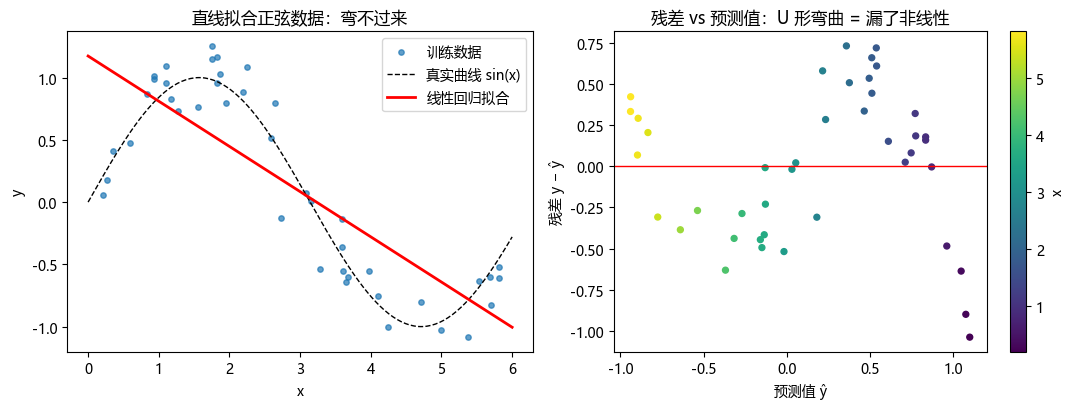

In [2]:
# ── 造数据：正弦曲线 + 高斯噪声 ──
rs = np.random.RandomState(42)
X_sin = np.sort(rs.uniform(0, 6, 60)).reshape(-1, 1)   # 60 个输入点
y_sin = np.sin(X_sin).ravel() + rs.normal(0, 0.2, 60)  # sin(x) + 噪声

X_tr, X_te, y_tr, y_te = train_test_split(X_sin, y_sin, test_size=0.3, random_state=42)

lin = LinearRegression().fit(X_tr, y_tr)
print(f'拟合直线: y = {lin.coef_[0]:.3f}x + {lin.intercept_:.3f}')
print(f'训练 R² = {lin.score(X_tr, y_tr):.3f}   测试 R² = {lin.score(X_te, y_te):.3f}')
mse = np.mean((y_te - lin.predict(X_te)) ** 2)
print(f'测试 MSE = {mse:.4f}   测试 RMSE = {np.sqrt(mse):.4f}（开根号回到 y 的原单位）')

# ── 残差图：健康残差应像"无规律的星空"，这里却有清晰的 U 形 ──
y_hat_tr = lin.predict(X_tr)
resid = y_tr - y_hat_tr
order = np.argsort(X_tr.ravel())

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
xs = np.linspace(0, 6, 200).reshape(-1, 1)
axes[0].scatter(X_tr, y_tr, s=15, alpha=0.7, label='训练数据')
axes[0].plot(xs, np.sin(xs), 'k--', lw=1, label='真实曲线 sin(x)')
axes[0].plot(xs, lin.predict(xs), 'r-', lw=2, label='线性回归拟合')
axes[0].set_title('直线拟合正弦数据：弯不过来')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y'); axes[0].legend()

sc = axes[1].scatter(y_hat_tr[order], resid[order], s=18, c=X_tr.ravel()[order], cmap='viridis')
axes[1].axhline(0, color='r', lw=1)
axes[1].set_title('残差 vs 预测值：U 形弯曲 = 漏了非线性')
axes[1].set_xlabel('预测值 ŷ'); axes[1].set_ylabel('残差 y − ŷ')
fig.colorbar(sc, ax=axes[1], label='x')
plt.tight_layout(); plt.show()

**小结**：训练 R²=0.656、测试 R²=0.425（与正文同款数字）——直线弯不过正弦，两边都不好（欠拟合）；右图残差不是随机星空，而是清晰的 U 形带（先正后负再正）——模型把"周期性"漏在了残差里。这就是残差四形态的第二种（弯曲）：解药是下一节的多项式特征。**回归做完先画残差图，是老工程师的肌肉记忆**。

## 实验 2：多项式次数 vs 过拟合——训练/测试误差双曲线

**目标**：同一份数据，把多项式次数从 1 扫到 15，画训练/测试 MSE 双曲线；并排看 1 / 3 / 15 次拟合线的长相。

**原理一句话**：模型容量加码，训练误差只降不升；测试误差先降后升——**训练分还在涨、测试分开始跌的"剪刀差"，就是过拟合的信号灯**。

正文对应：[线性回归 · 多项式回归](../docs/2-经典机器学习/03-机器学习/02-线性回归.md) 与 [模型评估与调优](../docs/2-经典机器学习/03-机器学习/07-模型评估与调优.md)

In [3]:
degrees = list(range(1, 16))
train_mse, test_mse = [], []
for d in degrees:
    # Pipeline：先造 x²、x³… 高次特征，再做线性回归——"对参数线性、对 x 不线性"
    model = make_pipeline(PolynomialFeatures(d), LinearRegression()).fit(X_tr, y_tr)
    train_mse.append(np.mean((y_tr - model.predict(X_tr)) ** 2))
    test_mse.append(np.mean((y_te - model.predict(X_te)) ** 2))

print(f'{"次数":>4s} {"训练MSE":>10s} {"测试MSE":>10s}')
for d, tr, te in zip(degrees, train_mse, test_mse):
    note = ('  ← 欠拟合：弯不过来' if d == 1 else
            '  ← 弯度刚好，训练测试齐头并进' if d == 3 else
            '  ← 训练误差更低但测试误差回升：过拟合' if d == 15 else '')
    print(f'{d:4d} {tr:10.4f} {te:10.4f}{note}')

best_d = degrees[int(np.argmin(test_mse))]
print(f'\n测试误差最小的次数 = {best_d}；15 次训练误差全场最低，测试误差却变差——分数漂亮≠模型好')

  次数      训练MSE      测试MSE
   1     0.1977     0.2527  ← 欠拟合：弯不过来
   2     0.1907     0.2154
   3     0.0338     0.0281  ← 弯度刚好，训练测试齐头并进
   4     0.0336     0.0289
   5     0.0322     0.0246
   6     0.0319     0.0256
   7     0.0306     0.0280
   8     0.0299     0.0296
   9     0.0293     0.0274
  10     0.0285     0.0324
  11     0.0284     0.0400
  12     0.0272     0.0313
  13     0.0250     0.0670
  14     0.0267     0.0423
  15     0.0255     0.0399  ← 训练误差更低但测试误差回升：过拟合

测试误差最小的次数 = 5；15 次训练误差全场最低，测试误差却变差——分数漂亮≠模型好


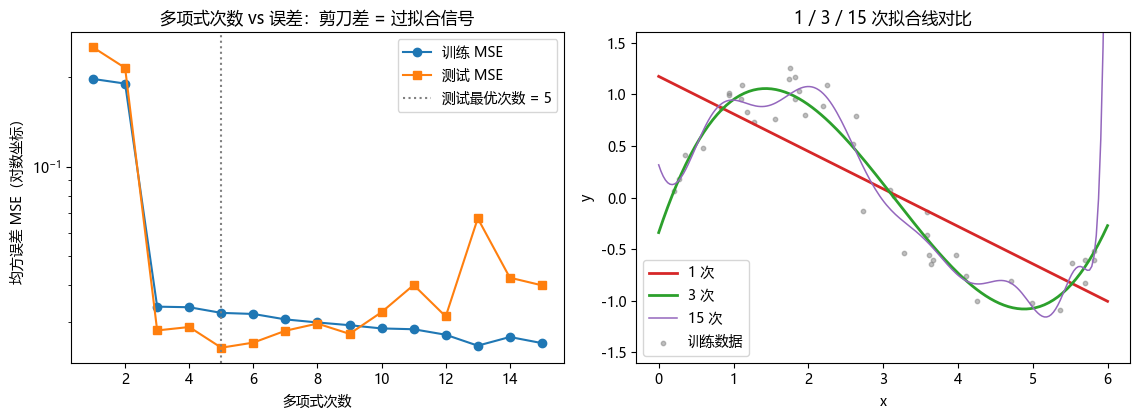

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))

axes[0].plot(degrees, train_mse, 'o-', label='训练 MSE')
axes[0].plot(degrees, test_mse, 's-', label='测试 MSE')
axes[0].axvline(best_d, color='gray', ls=':', label=f'测试最优次数 = {best_d}')
axes[0].set_yscale('log')
axes[0].set_title('多项式次数 vs 误差：剪刀差 = 过拟合信号')
axes[0].set_xlabel('多项式次数'); axes[0].set_ylabel('均方误差 MSE（对数坐标）')
axes[0].legend()

for d, color in [(1, 'tab:red'), (3, 'tab:green'), (15, 'tab:purple')]:
    model = make_pipeline(PolynomialFeatures(d), LinearRegression()).fit(X_tr, y_tr)
    axes[1].plot(xs, model.predict(xs), color=color, lw=2 if d != 15 else 1.1, label=f'{d} 次')
axes[1].scatter(X_tr, y_tr, s=10, alpha=0.5, color='gray', label='训练数据')
axes[1].set_ylim(-1.6, 1.6)
axes[1].set_title('1 / 3 / 15 次拟合线对比')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y'); axes[1].legend()

plt.tight_layout(); plt.show()

**小结**：次数 1 → 3 训练/测试误差一起跳水（补上了非线性）；3 → 15 训练误差继续微降、测试误差不再改善并在高端次数抬头，15 次的曲线在点与点之间疯狂扭动（右图紫色线）——把噪声也一丝不苟地背了下来。**模型不是越复杂越好**：容量要和"数据量 + 噪声水平"匹配，判断依据就是训练/测试的剪刀差。

## 实验 3：逻辑回归 + 混淆矩阵——乳腺癌数据集

**目标**：在 sklearn 内置乳腺癌数据集（569 个肿块、30 项检查指标）上训练逻辑回归，以"恶性"为我们关心的正类：画混淆矩阵热力图，**手算** 精确率/召回率/F1，再与 `classification_report` 对照。

**原理一句话**：$\hat p=\sigma(w^\top x+b)$ 过 0.5 门槛得类别；混淆矩阵把错误拆成"漏诊 FN"（危险）与"误诊 FP"（虚惊），P/R/F1 分别回答"警报准不准 / 漏没漏 / 一个数顾两边"。

正文对应：[逻辑回归与分类 · 混淆矩阵](../docs/2-经典机器学习/03-机器学习/03-逻辑回归与分类.md)

In [5]:
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                             precision_score, recall_score)

cancer = load_breast_cancer()
Xc, yc = cancer.data, cancer.target          # y：0 = 恶性，1 = 良性
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    Xc, yc, test_size=0.3, random_state=42, stratify=yc)

clf = LogisticRegression(max_iter=5000).fit(Xc_tr, yc_tr)
pred = clf.predict(Xc_te)

# 行 = 真实（良性、恶性），列 = 预测（良性、恶性）；labels=[1,0] 让良性排在第一行
cm = confusion_matrix(yc_te, pred, labels=[1, 0])
tn, fp, fn, tp = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]   # 以「恶性」为正类
print('混淆矩阵（行 = 真实，列 = 预测）:')
print('              预测良性   预测恶性')
print(f'实际良性     {tn:6d}   {fp:6d}    ← FP = 误诊（虚惊）')
print(f'实际恶性     {fn:6d}   {tp:6d}    ← FN = 漏诊（危险！）\n')

# ── 手算 P / R / F1，再用 sklearn 对照 ──
p_manual = tp / (tp + fp)
r_manual = tp / (tp + fn)
f1_manual = 2 * p_manual * r_manual / (p_manual + r_manual)
print(f'手算：精确率 = {tp}/({tp}+{fp}) = {p_manual:.3f}'
      f'   召回率 = {tp}/({tp}+{fn}) = {r_manual:.3f}   F1 = {f1_manual:.3f}')
print(f'sklearn：精确率 = {precision_score(yc_te, pred, pos_label=0):.3f}'
      f'   召回率 = {recall_score(yc_te, pred, pos_label=0):.3f}'
      f'   F1 = {f1_score(yc_te, pred, pos_label=0):.3f}\n')

print(classification_report(yc_te, pred, target_names=['恶性(正类)', '良性'], digits=3))

混淆矩阵（行 = 真实，列 = 预测）:
              预测良性   预测恶性
实际良性        105        2    ← FP = 误诊（虚惊）
实际恶性          7       57    ← FN = 漏诊（危险！）

手算：精确率 = 57/(57+2) = 0.966   召回率 = 57/(57+7) = 0.891   F1 = 0.927
sklearn：精确率 = 0.966   召回率 = 0.891   F1 = 0.927

              precision    recall  f1-score   support

      恶性(正类)      0.966     0.891     0.927        64
          良性      0.938     0.981     0.959       107

    accuracy                          0.947       171
   macro avg      0.952     0.936     0.943       171
weighted avg      0.948     0.947     0.947       171



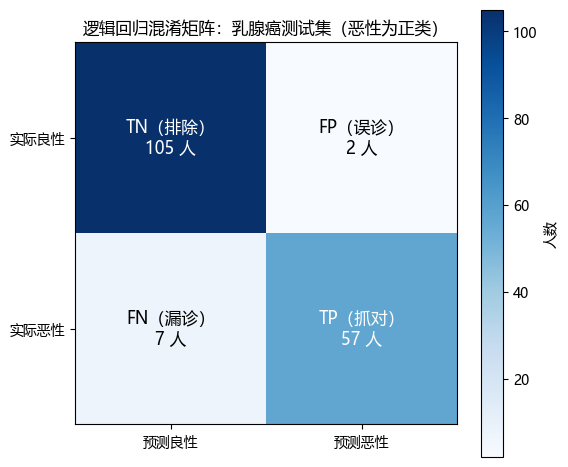

In [6]:
fig, ax = plt.subplots(figsize=(5.8, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['预测良性', '预测恶性']); ax.set_yticklabels(['实际良性', '实际恶性'])
tag = [['TN（排除）', 'FP（误诊）'], ['FN（漏诊）', 'TP（抓对）']]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{tag[i][j]}\n{cm[i, j]} 人', ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=12)
ax.set_title('逻辑回归混淆矩阵：乳腺癌测试集（恶性为正类）')
fig.colorbar(im, ax=ax, label='人数')
plt.tight_layout(); plt.show()

**小结**：混淆矩阵 [[105, 2], [7, 57]]（与正文一致）——57 个恶性被抓回、7 个漏诊、只有 2 个虚惊；手算的 P/R/F1（0.966 / 0.891 / 0.927）与 sklearn 逐位吻合，`classification_report` 再对一遍总账。漏诊（FN）和误诊（FP）的代价不对称时，不该死守 0.5 门槛——把判恶性的门槛降到 0.3 / 0.1，召回率上升、精确率下滑（见文末改参数建议）。

## 实验 4：决策边界可视化——两特征逻辑回归的"划线"

**目标**：只取"平均半径、平均纹理"两个特征训练逻辑回归，把概率面画成等高线图——0.5 那条等高线就是决策边界。

**原理一句话**：$\sigma(z)\ge 0.5 \Leftrightarrow z = w^\top x + b \ge 0$——Sigmoid 只负责翻译，真正划线的是直线 $w_1x_1+w_2x_2+b=0$。

正文对应：[逻辑回归与分类 · 决策边界](../docs/2-经典机器学习/03-机器学习/03-逻辑回归与分类.md)

学到的打分器: z = -1.0310×平均半径 + -0.1712×平均纹理 + 18.5100
决策边界（z=0 的直线）: 平均纹理 = 6.023×平均半径 − 108.132
z ≥ 0 → 判良性；半径越大、纹理越粗 → z 越小 → 越判恶性
只用 2/30 个特征的测试准确率 = 0.883


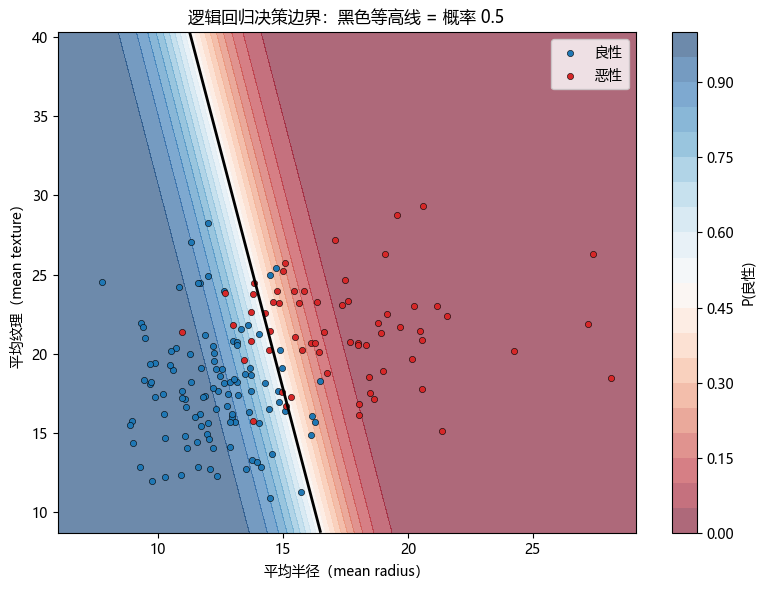

In [7]:
X2 = Xc[:, [0, 1]]                       # 只取 mean radius、mean texture 两个特征
X2_tr, X2_te, y2_tr, y2_te = train_test_split(
    X2, yc, test_size=0.3, random_state=42, stratify=yc)

clf2 = LogisticRegression(max_iter=5000).fit(X2_tr, y2_tr)
w1, w2, b = clf2.coef_[0, 0], clf2.coef_[0, 1], clf2.intercept_[0]
print(f'学到的打分器: z = {w1:.4f}×平均半径 + {w2:.4f}×平均纹理 + {b:.4f}')
print(f'决策边界（z=0 的直线）: 平均纹理 = {w1 / w2:.3f}×平均半径 − {-b / w2:.3f}')
print('z ≥ 0 → 判良性；半径越大、纹理越粗 → z 越小 → 越判恶性')
print(f'只用 2/30 个特征的测试准确率 = {clf2.score(X2_te, y2_te):.3f}')

# ── 概率面等高线 + 0.5 决策边界 ──
gx = np.linspace(X2[:, 0].min() - 1, X2[:, 0].max() + 1, 300)
gy = np.linspace(X2[:, 1].min() - 1, X2[:, 1].max() + 1, 300)
XX, YY = np.meshgrid(gx, gy)
ZZ = clf2.predict_proba(np.c_[XX.ravel(), YY.ravel()])[:, 1].reshape(XX.shape)

fig, ax = plt.subplots(figsize=(8, 6))
cf = ax.contourf(XX, YY, ZZ, levels=20, cmap='RdBu', alpha=0.6)
ax.contour(XX, YY, ZZ, levels=[0.5], colors='k', linewidths=2)   # 黑线 = 决策边界
ax.scatter(X2_te[y2_te == 1, 0], X2_te[y2_te == 1, 1], s=20, c='tab:blue',
           edgecolors='k', linewidths=0.4, label='良性')
ax.scatter(X2_te[y2_te == 0, 0], X2_te[y2_te == 0, 1], s=20, c='tab:red',
           edgecolors='k', linewidths=0.4, label='恶性')
ax.set_title('逻辑回归决策边界：黑色等高线 = 概率 0.5')
ax.set_xlabel('平均半径（mean radius）'); ax.set_ylabel('平均纹理（mean texture）')
ax.legend(loc='upper right')
fig.colorbar(cf, ax=ax, label='P(良性)')
plt.tight_layout(); plt.show()

**小结**：背景色是"良性的概率"，从蓝到红平滑过渡；黑色 0.5 等高线是一条**直线**——"决策边界是直线"眼见为实。半径越大、纹理越粗糙，越落在"恶性"一侧。只用 2 个特征准确率就有 0.883，剩下的 28 个特征锦上添花；但要弯的边界（比如把月牙形数据分开），线性打分器无能为力，得靠实验 5 的树模型。

## 实验 5：随机森林 vs 单棵树——集成降方差 + 特征重要性

**目标**：wine 数据集（178 款酒、13 项理化指标、3 个品种）上对比单棵树与随机森林的测试精度及波动，并画特征重要性条形图——树模型顺便告诉你"哪个问题最关键"。

**原理一句话**：单棵树高方差（换颗随机种子结果就变）；随机森林让上百棵"略不同的树"各自训练、集体投票，把方差平均掉——**用一群不稳定的学习器，换一个稳定的好学习器**。

正文对应：[决策树与集成学习](../docs/2-经典机器学习/03-机器学习/04-决策树与集成学习.md)

单棵树 5 个种子的测试准确率: [0.956 0.933 0.956 0.956 0.956]  均值 0.951 ± 0.009
随机森林(100 棵) 测试准确率: 1.000
—— 单棵树忽高忽低（高方差），森林把一群树的方差平均掉了


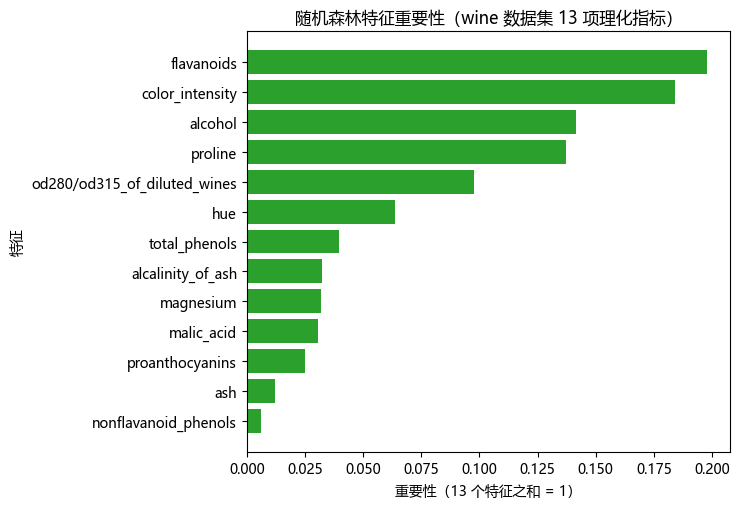

前三关键特征: [('flavanoids', 0.198), ('color_intensity', 0.184), ('alcohol', 0.142)]


In [8]:
from sklearn.datasets import load_wine
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

wine = load_wine()
Xw, yw = wine.data, wine.target
Xw_tr, Xw_te, yw_tr, yw_te = train_test_split(Xw, yw, random_state=42)

# ── 单棵树有多"飘"：换 5 颗随机种子看波动 ──
tree_scores = [DecisionTreeClassifier(random_state=s).fit(Xw_tr, yw_tr).score(Xw_te, yw_te)
               for s in range(5)]
forest = RandomForestClassifier(n_estimators=100, random_state=42).fit(Xw_tr, yw_tr)

print('单棵树 5 个种子的测试准确率:', np.round(tree_scores, 3),
      f' 均值 {np.mean(tree_scores):.3f} ± {np.std(tree_scores):.3f}')
print(f'随机森林(100 棵) 测试准确率: {forest.score(Xw_te, yw_te):.3f}')
print('—— 单棵树忽高忽低（高方差），森林把一群树的方差平均掉了')

# ── 特征重要性：模型自己报告"哪一问最关键" ──
importance = forest.feature_importances_
order5 = np.argsort(importance)

fig, ax = plt.subplots(figsize=(7.5, 5.2))
ax.barh(np.array(wine.feature_names)[order5], importance[order5], color='tab:green')
ax.set_title('随机森林特征重要性（wine 数据集 13 项理化指标）')
ax.set_xlabel('重要性（13 个特征之和 = 1）'); ax.set_ylabel('特征')
plt.tight_layout(); plt.show()

top3 = np.argsort(importance)[::-1][:3]
print('前三关键特征:', [(wine.feature_names[i], round(importance[i], 3)) for i in top3])

**小结**：单棵树 5 颗种子在 0.933~0.956 之间摆动，100 棵的森林稳定到 1.0——集成的本质就是**降方差**；特征重要性榜首是 flavonoids（类黄酮 0.198）、其次是 color_intensity（颜色深度 0.184）——不用查酿造文献，模型自己告诉你"第一问该问什么"。想要更好的表格式数据基线，先试梯度提升树（GBDT 家族），思路同源。

## 实验 6：K-Means 两轮手推复现——8 个点的"归队 → 挪中心"

**目标**：用正文的 8 个二维点、**故意选坏的初始中心**（两个都挤在左下角），手写循环逐轮打印归属变化直到收敛；再与 sklearn 对照，画最终聚类图。

**原理一句话**：K-Means = "就近归队（把每个点分给最近的中心）→ 重算质心（中心挪到本簇均值）"反复交替，归属不再变化即收敛；但只保证局部最优——这就是 sklearn 默认 `n_init` 多次重启的原因。

正文对应：[聚类与降维 · 举个例子：K-Means 手推](../docs/2-经典机器学习/03-机器学习/06-聚类与降维.md)

In [9]:
points = np.array([[1, 1], [2, 1], [1, 3], [2, 3],    # 左下角一团
                   [8, 7], [9, 7], [8, 9], [9, 9]])    # 右上角一团
names6 = [f'P{i + 1}' for i in range(8)]
centers = np.array([[1.0, 1.0], [2.0, 3.0]])           # 故意选坏：两个中心都在左下角

def sse_of(points, labels, centers):
    """簇内平方和（sklearn 叫 inertia_）：每点到本簇中心的距离平方求和"""
    return sum(((p - centers[l]) ** 2).sum() for p, l in zip(points, labels))

prev = np.full(8, -1)
for it in range(1, 11):
    # E 步：就近归队——8×2 的距离表，每点选更近的中心
    d = np.linalg.norm(points[:, None, :] - centers[None, :, :], axis=2)
    labels = d.argmin(axis=1)
    changed = [names6[i] for i in range(8) if labels[i] != prev[i]]
    print(f'第 {it} 轮：中心 c1={centers[0].round(2)}, c2={centers[1].round(2)}')
    print(f'        归属 = {labels.tolist()}（0/1 = 簇1/簇2）'
          f'  换桌: {changed if changed else "无 → 收敛"}')
    print(f'        SSE（簇内平方和）= {sse_of(points, labels, centers):.2f}')
    if not changed:
        c1_members = [names6[i] for i in range(8) if labels[i] == 0]
        c2_members = [names6[i] for i in range(8) if labels[i] == 1]
        print(f'\n收敛！簇1 = {c1_members} 中心 {centers[0].round(2)}；'
              f'簇2 = {c2_members} 中心 {centers[1].round(2)}')
        break
    for k in range(2):                       # M 步：重算质心
        centers[k] = points[labels == k].mean(axis=0)
    prev = labels.copy()

第 1 轮：中心 c1=[1. 1.], c2=[2. 3.]
        归属 = [0, 0, 1, 1, 1, 1, 1, 1]（0/1 = 簇1/簇2）  换桌: ['P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8']
        SSE（簇内平方和）= 276.00
第 2 轮：中心 c1=[1.5 1. ], c2=[6.17 6.33]
        归属 = [0, 0, 0, 0, 1, 1, 1, 1]（0/1 = 簇1/簇2）  换桌: ['P3', 'P4']
        SSE（簇内平方和）= 46.89
第 3 轮：中心 c1=[1.5 2. ], c2=[8.5 8. ]
        归属 = [0, 0, 0, 0, 1, 1, 1, 1]（0/1 = 簇1/簇2）  换桌: 无 → 收敛
        SSE（簇内平方和）= 10.00

收敛！簇1 = ['P1', 'P2', 'P3', 'P4'] 中心 [1.5 2. ]；簇2 = ['P5', 'P6', 'P7', 'P8'] 中心 [8.5 8. ]


In [10]:
# ── 与 sklearn 对照：喂同样的坏初始中心，结果应逐位一致 ──
from sklearn.cluster import KMeans

km = KMeans(n_clusters=2, init=points[[0, 3]], n_init=1, random_state=42).fit(points)
print('sklearn 归属  :', km.labels_.tolist())
print('sklearn 中心  :', km.cluster_centers_.round(2).tolist())
print('sklearn SSE   :', km.inertia_, '（手推最终也是 10.0：每点离质心 √1.25，8 点 × 1.25）')

sklearn 归属  : [0, 0, 0, 0, 1, 1, 1, 1]
sklearn 中心  : [[1.5, 2.0], [8.5, 8.0]]
sklearn SSE   : 10.0 （手推最终也是 10.0：每点离质心 √1.25，8 点 × 1.25）


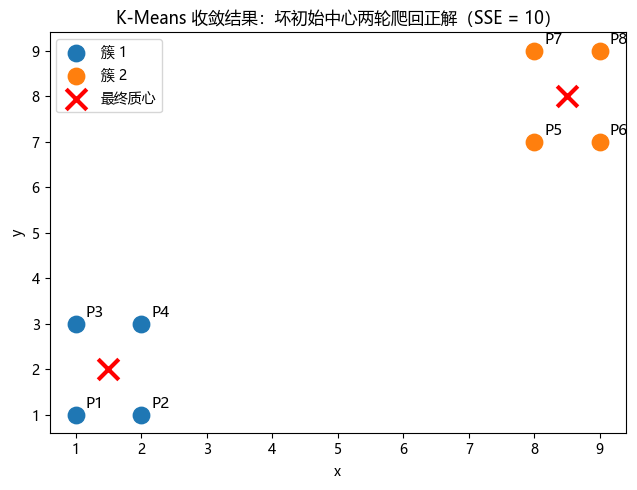

In [11]:
fig, ax = plt.subplots(figsize=(6.5, 5))
for k, color, name in [(0, 'tab:blue', '簇 1'), (1, 'tab:orange', '簇 2')]:
    pts = points[km.labels_ == k]
    ax.scatter(pts[:, 0], pts[:, 1], s=140, c=color, label=name)
for (px, py), nm in zip(points, names6):
    ax.annotate(nm, (px, py), xytext=(px + 0.15, py + 0.15), fontsize=11)
ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], marker='x',
           s=220, c='red', linewidths=3, label='最终质心')
ax.set_title('K-Means 收敛结果：坏初始中心两轮爬回正解（SSE = 10）')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.legend()
plt.tight_layout(); plt.show()

**小结**：初始中心选坏后，第 1 轮右上 4 个点被"错收编"进左下簇（SSE 高达 276）；第 2 轮 P3、P4 换桌（SSE 降到 46.9），中心随之挪到 (1.5, 2) 与 (8.5, 8)——正好落回两团数据的质心；第 3 轮无人换桌 → 收敛，SSE = 10，与 sklearn 完全一致。K-Means 每轮都在降 SSE、必然收敛，但只收敛到**局部**最优——初始中心太坏时要绕路，更坏时甚至停在错误答案上。

## 实验 7：交叉验证与学习曲线——给模型"看片诊断"

**目标**：乳腺癌全量数据上做 5 折交叉验证报 AUC 均值±标准差；再画两张学习曲线——逻辑回归（拟合良好）与全深度决策树（过拟合）——练"剪刀差读片"。

**原理一句话**：K 折交叉验证把数据切成 K 份轮流当验证集，均值±方差比单次划分更诚实；学习曲线看"训练分 vs 验证分随样本量的走向"——**两条线双低贴合 = 欠拟合（高偏差），训练高验证低 = 过拟合（高方差）**。

正文对应：[模型评估与调优 · 学习曲线](../docs/2-经典机器学习/03-机器学习/07-模型评估与调优.md)

5 折各自的 AUC: [0.9948 0.9967 0.997  0.9878 0.9997]
汇总：AUC = 0.9952 ± 0.0040（均值±波动一起报，才是一次诚实的评估）


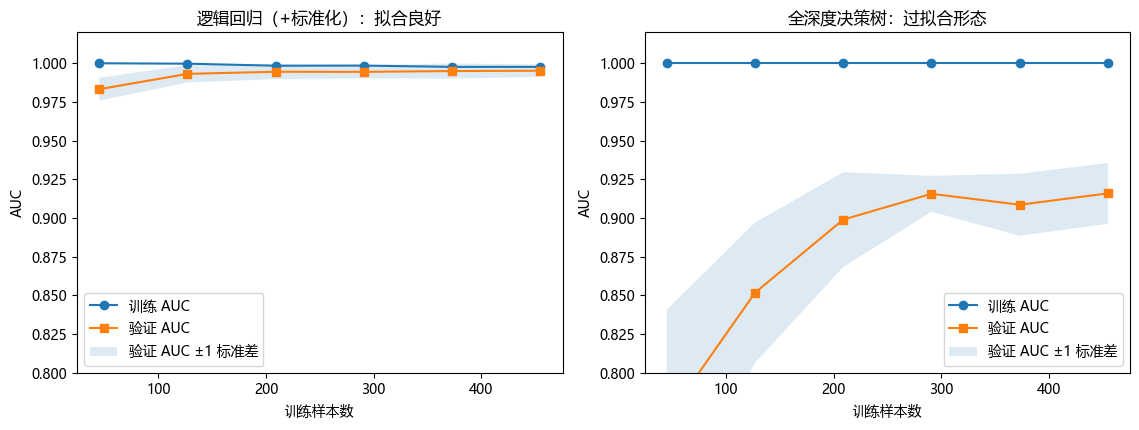

决策树最后一档：训练 AUC = 1.000, 验证 AUC = 0.916 → 剪刀差 = 0.084（训练分钉死 1.0，验证分低一档）


In [12]:
from sklearn.tree import DecisionTreeClassifier

# ── 5 折交叉验证：AUC 均值 ± 标准差（标准化装进 Pipeline，防止预处理泄漏，见实验 8）──
pipe_lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
auc_scores = cross_val_score(pipe_lr, Xc, yc, cv=5, scoring='roc_auc')
print('5 折各自的 AUC:', np.round(auc_scores, 4))
print(f'汇总：AUC = {auc_scores.mean():.4f} ± {auc_scores.std():.4f}'
      '（均值±波动一起报，才是一次诚实的评估）')

# ── 学习曲线：逻辑回归 vs 全深度决策树 ──
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
for ax, model, title in [
        (axes[0], pipe_lr, '逻辑回归（+标准化）：拟合良好'),
        (axes[1], DecisionTreeClassifier(random_state=42), '全深度决策树：过拟合形态')]:
    sz, tr_sc, va_sc = learning_curve(model, Xc, yc, cv=5, scoring='roc_auc',
                                      train_sizes=np.linspace(0.1, 1.0, 6))
    ax.plot(sz, tr_sc.mean(1), 'o-', label='训练 AUC')
    ax.plot(sz, va_sc.mean(1), 's-', label='验证 AUC')
    ax.fill_between(sz, va_sc.mean(1) - va_sc.std(1), va_sc.mean(1) + va_sc.std(1),
                    alpha=0.15, label='验证 AUC ±1 标准差')
    ax.set_title(title); ax.set_xlabel('训练样本数'); ax.set_ylabel('AUC')
    ax.set_ylim(0.80, 1.02); ax.legend()

plt.tight_layout(); plt.show()

gap = tr_sc.mean(1)[-1] - va_sc.mean(1)[-1]
print(f'决策树最后一档：训练 AUC = {tr_sc.mean(1)[-1]:.3f}, 验证 AUC = {va_sc.mean(1)[-1]:.3f}'
      f' → 剪刀差 = {gap:.3f}（训练分钉死 1.0，验证分低一档）')

**小结**：逻辑回归 5 折 AUC = 0.995 ± 0.004——均值很高、波动很小；左图训练/验证两条线贴合且同处高位（拟合良好），右图决策树训练 AUC 钉死 1.0、验证 AUC 明显低一档（最后一档 1.000 vs 0.916，剪刀差 0.084）——**训练分虚高、验证分跟不上，就是过拟合的标准片**。若两条线"双低贴合"才是欠拟合，该加复杂度；验证分随样本量还在爬升，说明加数据还有救。

## 实验 8：数据泄漏现场——"先标准化后划分"偷看了什么

**目标**：两个现场。现场一：先对全量数据标准化再划分 vs Pipeline 正确做法，看测试分差——并用 30 个种子揭示真相；现场二（更凶）：在全量数据上做特征选择，测试分虚高 12 个百分点。

**原理一句话**：任何"用了测试集信息"的预处理（求均值方差、挑特征、降维、目标编码）都是泄漏——测试集在考试前偷看了考卷，离线分数虚高、上线现出原形。防线只有一条：**所有 fit 都只发生在训练集上，用 Pipeline 把预处理关进笼子**。

正文对应：[模型评估与调优 · 数据泄漏](../docs/2-经典机器学习/03-机器学习/07-模型评估与调优.md)

In [13]:
from sklearn.neighbors import KNeighborsClassifier

# ── 现场一：标准化泄漏（单次划分 + 30 个种子复查）──
X1_tr, X1_te, y1_tr, y1_te = train_test_split(Xc, yc, test_size=0.3,
                                              random_state=42, stratify=yc)
# ❌ 错误：在全量数据上 fit 标准化（均值/方差里混进了测试集的信息），再各自 transform
scaler_all = StandardScaler().fit(Xc)
knn_wrong = KNeighborsClassifier().fit(scaler_all.transform(X1_tr), y1_tr)
acc_wrong = knn_wrong.score(scaler_all.transform(X1_te), y1_te)
# ✅ 正确：Pipeline 把「fit 标准化」关进训练集内部，测试集只被 transform
pipe_knn = make_pipeline(StandardScaler(), KNeighborsClassifier()).fit(X1_tr, y1_tr)
acc_right = pipe_knn.score(X1_te, y1_te)

print(f'❌ 先标准化后划分：测试准确率 = {acc_wrong:.4f}')
print(f'✅ Pipeline 正确做法：测试准确率 = {acc_right:.4f}')
print(f'   单次分差 = {acc_wrong - acc_right:+.4f}（这次看起来"错误做法更好"）\n')

# 单次划分会骗人——换 30 个种子复查
diffs = []
for seed in range(30):
    a, b, c, d = train_test_split(Xc, yc, test_size=0.3, random_state=seed, stratify=yc)
    s = StandardScaler().fit(Xc)                     # ❌ 全量 fit
    w = KNeighborsClassifier().fit(s.transform(a), c).score(s.transform(b), d)
    r = make_pipeline(StandardScaler(), KNeighborsClassifier()).fit(a, c).score(b, d)
    diffs.append(w - r)
diffs = np.array(diffs)
print(f'30 个种子的分差：均值 {diffs.mean():+.4f} ± {diffs.std():.4f}，'
      f'为正的比例仅 {(diffs > 0).mean():.0%}')
print('→ 标准化只"偷看"了均值/方差两个数：在独立同分布数据上，这点泄漏几乎测不出伤害；')
print('  但它依然是泄漏——一旦数据有时间结构/分组结构（分布漂移），偷看的统计量立刻变成作弊')

❌ 先标准化后划分：测试准确率 = 0.9708
✅ Pipeline 正确做法：测试准确率 = 0.9591
   单次分差 = +0.0117（这次看起来"错误做法更好"）



30 个种子的分差：均值 +0.0002 ± 0.0035，为正的比例仅 13%
→ 标准化只"偷看"了均值/方差两个数：在独立同分布数据上，这点泄漏几乎测不出伤害；
  但它依然是泄漏——一旦数据有时间结构/分组结构（分布漂移），偷看的统计量立刻变成作弊


In [14]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.datasets import make_classification

# ── 现场二：特征选择泄漏（偷看的不再是均值方差，而是"谁和标签相关"）──
Xn, yn = make_classification(n_samples=200, n_features=2000, n_informative=5,
                             n_redundant=0, shuffle=False, random_state=42)
Xn_tr, Xn_te, yn_tr, yn_te = train_test_split(Xn, yn, test_size=0.3, random_state=42)
print(f'造数据：200 个样本 × 2000 个特征，其中只有 5 个真的和标签有关，其余 1995 个纯噪声\n')

# ❌ 错误：在全量数据上挑"与标签最相关"的 10 个特征，再划分训练测试
sel_all = SelectKBest(f_classif, k=10).fit(Xn, yn)          # fit 时用了全量标签！
clf_wrong = LogisticRegression(max_iter=5000).fit(sel_all.transform(Xn_tr), yn_tr)
acc2_wrong = clf_wrong.score(sel_all.transform(Xn_te), yn_te)

# ✅ 正确：特征选择装进 Pipeline，只在训练集上挑
pipe_sel = make_pipeline(SelectKBest(f_classif, k=10),
                         LogisticRegression(max_iter=5000)).fit(Xn_tr, yn_tr)
acc2_right = pipe_sel.score(Xn_te, yn_te)

print(f'❌ 全量挑特征后划分：测试准确率 = {acc2_wrong:.3f}'
      '（挑特征时偷看了测试集的标签，噪声特征也因此显得"相关"）')
print(f'✅ Pipeline 内挑特征：测试准确率 = {acc2_right:.3f}')
print(f'   分差 = {acc2_wrong - acc2_right:+.3f} —— 这才是泄漏的真面目：离线分数虚高')

造数据：200 个样本 × 2000 个特征，其中只有 5 个真的和标签有关，其余 1995 个纯噪声

❌ 全量挑特征后划分：测试准确率 = 0.783（挑特征时偷看了测试集的标签，噪声特征也因此显得"相关"）
✅ Pipeline 内挑特征：测试准确率 = 0.667
   分差 = +0.117 —— 这才是泄漏的真面目：离线分数虚高


**小结**：现场一里标准化泄漏的分差在 30 个种子上平均只有 +0.0002、方向随机——**"测不出伤害"≠"没泄漏"**，它偷看的只是均值/方差两个统计量，在独立同分布数据上危害有限；现场二把"偷看权"升级到标签，测试分立刻虚高 0.117——挑出来的 5 个"最强噪声特征"是看着测试集标签选的。工程防线一句话：**预处理全部装进 Pipeline / 只在训练折上 fit**，让测试集从头到尾只被 `transform`。

## 改参数建议（自己动手玩）

1. **实验 1/2**：把噪声从 0.2 加到 0.5（改 `rs.normal(0, 0.2, 60)`）——残差带变宽，测试误差整体抬升，测试最优次数向低处移动：**数据越吵，养活得起的模型越简单**。
2. **实验 3**：用 `prob = clf.predict_proba(Xc_te)[:, 0]` 拿恶性概率，手动按 `(prob >= 0.3)` / `(prob >= 0.1)` 判类——召回率单调上升、精确率下滑，亲手画一遍"宁错杀不放过"的代价曲线（正文同款实验）。
3. **实验 5**：把 `n_estimators` 从 100 降到 5——森林分数往往下滑（树太少，投票的"民意"不稳）；再加 `oob_score=True` 看 OOB 分，白赚一个免划分的验证指标。
4. **实验 6**：把初始中心换成 P1 和 P2（两个都在左下角且更近）——看它多绕几轮才收敛、SSE 停在多少；再把 K 换成 3，SSE 从 10 降到 6——配合"肘部法则"想想 K 该选几。
5. **实验 7/8**：把左图模型换成 `DecisionTreeClassifier(max_depth=1)`（树桩）——两条线"双低贴合"：高偏差（欠拟合）形态；把实验 8 的 `k=10` 改成 `k=50`——现场二的虚高分差会变小（偷看的重要性被稀释），泄漏的危害程度取决于"偷看的信息值多少分"。

---

返回：[Notebook 目录](./README.md) · [第 3 章正文](../docs/2-经典机器学习/03-机器学习/README.md)